# Chi phí biên + Uncertainty vào bài toán định giá

Notebook này sửa **hai lỗ hổng** của `00_TONG_HOP_chay_1_the.ipynb` Phần 7–8.

## Lỗ hổng 1 — tối ưu **doanh thu**, không phải **lợi nhuận**

Hàm `ty_le_toi_uu()` hiện tối đa hoá `p · P(chấp nhận)`. Không có chi phí thì **không có gì hãm
việc giảm giá** ngoài độ cong đường logit ⇒ nghiệm luôn nằm sâu dưới giá đối thủ (0,7598×), ở
**mọi bối cảnh**. Doanh nghiệp thật tối đa hoá `(p − MC) · Q`.

$$\Pi(p) \;=\; (p - MC)\cdot P(\text{chấp nhận} \mid p)$$

## Lỗ hổng 2 — cắm thẳng **ước lượng điểm** `p̂` vào quyết định

Model giá có MAE 18.048đ (14,74%). Quyết định như thể `p̂` là đúng ⇒ **quá tự tin**. Công thức đúng
lấy tích phân trên **phân phối dự đoán**:

$$\mathbb{E}[\Pi(p)] \;=\; \int (p - MC)\cdot P(\text{chấp nhận} \mid p,\, p_{\text{đối thủ}})
\cdot f(p_{\text{đối thủ}} \mid \text{dữ liệu})\; dp_{\text{đối thủ}}$$

Đây là **mắt xích nối cả 3 cấu phần đề bài**: model giá → uncertainty → quyết định giá.

---

## Phân biệt 2 loại "chi phí" — dễ nhầm

| | Đo cái gì | Lấy lại được không |
|---|---|---|
| `04_mo_phong_dau_cuoi` đo **3.381đ/chuyến** | Cái giá của việc model **SAI** (oracle vs `p̂`) | ❌ Chỉ giảm được bằng model tốt hơn |
| Notebook này đo | Cái giá của việc **VỜ NHƯ** model đúng | ✅ **Lấy lại được miễn phí** — chỉ đổi cách chọn giá |

---

## Đầu vào

| File | Dùng để |
|---|---|
| `evaluation/qr_pred_calibration.parquet` (615.908) | Dựng phân phối dự đoán — **chọn** giá |
| `evaluation/qr_pred_test.parquet` (864.360) | **Đánh giá** ngoài mẫu |

Đã kiểm chứng 2 file khớp hàng 100% với `uq_pred_test.parquet`.

⚠️ **Vẫn là mô phỏng dưới giả định elasticity** — dữ liệu không có nhãn accept/reject.
Notebook này không sửa được điều đó; nó chỉ làm bài toán *quyết định* đúng hơn.

In [1]:
import warnings, sys
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})
pd.set_option("display.width", 150)

EVAL = Path("../evaluation")
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

# ── Tham so model chap nhan (giu NGUYEN nhu 00_TONG_HOP de so sanh duoc) ──
P0      = 0.50          # ty le chap nhan tai gia ngang bang doi thu
EPS     = -2.0          # elasticity FIRM-level (chinh)
EPS_DAI = [-1.2, -2.0, -3.0]

A_LOGIT = np.log(P0 / (1 - P0))      # = 0 khi P0 = 0.5


def P_accept(ty_le, eps=EPS, P0=P0, dich_WTP=0.0):
    """ty_le = gia_minh / gia_doi_thu_THAT."""
    b = eps / (1 - P0)
    a = np.log(P0 / (1 - P0))
    return 1 / (1 + np.exp(-(a + b * (np.log(ty_le) - np.log1p(dich_WTP)))))


assert abs(P_accept(1.0) - P0) < 1e-12, "Tai gia ngang bang phai ra dung P0"
print(f"P0 = {P0} | eps = {EPS} (firm-level) | b = {EPS/(1-P0):.1f}")
print("Kiem tra: P_accept(1.0) =", P_accept(1.0))

P0 = 0.5 | eps = -2.0 (firm-level) | b = -4.0
Kiem tra: P_accept(1.0) = 0.5


## 1. Nạp dữ liệu & dựng phân phối dự đoán

Ý tưởng: chuẩn hoá mọi thứ theo `p̂ = q50` (ước lượng điểm giá đối thủ).

| Ký hiệu | Nghĩa |
|---|---|
| `r` | tỷ lệ giá **mình** báo so với `p̂` — **biến quyết định** |
| `u` | tỷ lệ giá đối thủ **THẬT** so với `p̂` — **biến ngẫu nhiên**, đây chính là uncertainty |
| `c` | chi phí biên tính theo phần của `p̂` |

Khi đó tỷ lệ khách so sánh là `r/u`, và lợi nhuận kỳ vọng (chia cho `p̂`) chỉ còn phụ thuộc `r`, `c`
và **phân phối của `u`** — không phụ thuộc từng chuyến:

$$\frac{\mathbb{E}[\Pi]}{\hat p} \;=\; (r - c)\cdot \mathbb{E}_u\!\left[\sigma\!\left(a + b\ln\frac{r}{u}\right)\right]$$

`u` lấy **thực nghiệm** từ tập calibration — không giả định phân phối chuẩn hay lognormal.

In [2]:
qc = pd.read_parquet(EVAL / "qr_pred_calibration.parquet")
qt = pd.read_parquet(EVAL / "qr_pred_test.parquet")

u_cal = (qc.gia_that / qc.q50).values     # DUNG DE CHON gia
u_test = (qt.gia_that / qt.q50).values    # DUNG DE DANH GIA ngoai mau

print(f"Calibration : {len(u_cal):,} chuyen")
print(f"Test        : {len(u_test):,} chuyen")
print()
print(f"{'':16s} {'TB':>8s} {'std':>8s} {'p05':>8s} {'p50':>8s} {'p95':>8s}")
for ten, u in [("calibration", u_cal), ("test", u_test)]:
    q = np.percentile(u, [5, 50, 95])
    print(f"{ten:16s} {u.mean():8.4f} {u.std():8.4f} {q[0]:8.4f} {q[1]:8.4f} {q[2]:8.4f}")

print()
print("=> Model gia KHONG lech he thong (TB ~ 1.0) nhung PHAN TAN rong (std ~ 0.19).")
print("   Chinh do phan tan nay la thu Phan 7 cua 00_TONG_HOP dang bo qua.")
print()
cov = ((qt.gia_that >= qt.q05) & (qt.gia_that <= qt.q95)).mean()
print(f"Coverage khoang q05-q95 tren test: {cov:.2%} (danh muc 90%)")

Calibration : 615,908 chuyen
Test        : 864,360 chuyen

                       TB      std      p05      p50      p95
calibration        1.0101   0.1934   0.7247   0.9927   1.3558
test               1.0246   0.1987   0.7326   1.0051   1.3802

=> Model gia KHONG lech he thong (TB ~ 1.0) nhung PHAN TAN rong (std ~ 0.19).
   Chinh do phan tan nay la thu Phan 7 cua 00_TONG_HOP dang bo qua.

Coverage khoang q05-q95 tren test: 89.09% (danh muc 90%)


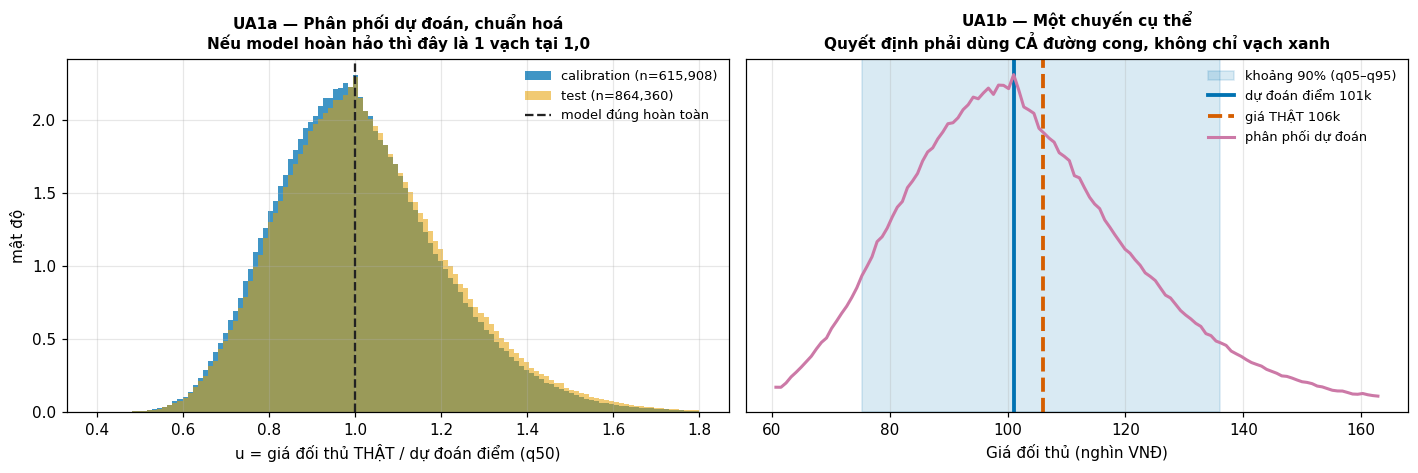

In [3]:
# ═════════ HINH UA1 — phan phoi du doan ═════════
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

ax[0].hist(u_cal, bins=120, range=(0.4, 1.8), color=BLUE, alpha=.75,
           density=True, label=f"calibration (n={len(u_cal):,})")
ax[0].hist(u_test, bins=120, range=(0.4, 1.8), color=ORANGE, alpha=.55,
           density=True, label=f"test (n={len(u_test):,})")
ax[0].axvline(1.0, color="#222", ls="--", lw=1.5, label="model đúng hoàn toàn")
ax[0].set_xlabel("u = giá đối thủ THẬT / dự đoán điểm (q50)")
ax[0].set_ylabel("mật độ"); ax[0].legend(frameon=False, fontsize=8.5)
ax[0].set_title("UA1a — Phân phối dự đoán, chuẩn hoá\nNếu model hoàn hảo thì đây là 1 vạch tại 1,0",
                fontweight="bold", fontsize=10)

# Minh hoa: 1 chuyen cu the
i = 0
p_hat = qt.q50.iloc[i]
ax[1].axvspan(qt.q05.iloc[i]/1000, qt.q95.iloc[i]/1000, color=BLUE, alpha=.15,
              label="khoảng 90% (q05–q95)")
ax[1].axvline(p_hat/1000, color=BLUE, lw=2.5, label=f"dự đoán điểm {p_hat/1000:.0f}k")
ax[1].axvline(qt.gia_that.iloc[i]/1000, color=RED, lw=2.5, ls="--",
              label=f"giá THẬT {qt.gia_that.iloc[i]/1000:.0f}k")
gr = np.linspace(qt.q05.iloc[i]*0.8, qt.q95.iloc[i]*1.2, 400)
dens = np.histogram(p_hat*u_cal, bins=120, range=(gr[0], gr[-1]), density=True)
ax[1].plot((dens[1][:-1]+dens[1][1:])/2/1000, dens[0]/dens[0].max()*ax[1].get_ylim()[1]*0.9,
           color=PURPLE, lw=2, label="phân phối dự đoán")
ax[1].set_xlabel("Giá đối thủ (nghìn VNĐ)"); ax[1].set_yticks([])
ax[1].legend(frameon=False, fontsize=8.5, loc="upper right")
ax[1].set_title("UA1b — Một chuyến cụ thể\nQuyết định phải dùng CẢ đường cong, không chỉ vạch xanh",
                fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "UA1_phanphoi_dudoan.png"); plt.show()

## 2. Lỗ hổng 1 — đưa **chi phí biên** vào

### Chi phí biên của một cuốc xe là gì?

Không phải chi phí của nền tảng (gần bằng 0), mà là **khoản phải trả tài xế** — dưới mức đó thì
tài xế không nhận cuốc. Ở thị trường gọi xe Việt Nam, tài xế thường nhận **~75–80%** cước.

Vì chưa có số chính thức, ta để `c = MC / p̂` làm **tham số** và quét cả dải, đúng cách đã làm với
elasticity.

In [4]:
R_GRID = np.linspace(0.40, 2.00, 1601)     # ty le gia minh / p_hat


def loi_nhuan_ky_vong(r, c, u, eps=EPS, P0=P0):
    """E[Pi]/p_hat. r co the la scalar hoac mang; u la mang mau."""
    r = np.atleast_1d(r).astype(float)
    # ma tran (len(r), len(u)) co the rat lon -> tinh theo tung r
    out = np.empty(len(r))
    b = eps / (1 - P0); a = np.log(P0 / (1 - P0))
    for j, rj in enumerate(r):
        P = 1 / (1 + np.exp(-(a + b * (np.log(rj) - np.log(u)))))
        out[j] = (rj - c) * P.mean()
    return out


def toi_uu(c, u, eps=EPS, P0=P0):
    v = loi_nhuan_ky_vong(R_GRID, c, u, eps, P0)
    k = int(np.argmax(v))
    return R_GRID[k], v[k], k


# u = 1 tuc la BO QUA bat dinh (dung y het Phan 7 cua 00_TONG_HOP)
u_chac_chan = np.ones(1)

rows = []
for c in [0.0, 0.20, 0.40, 0.50, 0.60, 0.70, 0.75, 0.80]:
    r_star, pi, k = toi_uu(c, u_chac_chan)
    rows.append({"c (MC/p̂)": f"{c:.0%}", "r* (giá/p̂)": round(r_star, 4),
                 "so với đối thủ": f"{(r_star-1)*100:+.1f}%",
                 "P(chấp nhận)": f"{P_accept(r_star):.1%}",
                 "E[Π]/p̂": round(pi, 4),
                 "ở biên lưới?": "⚠️ CÓ" if k in (0, len(R_GRID)-1) else "không"})
bang_c = pd.DataFrame(rows)
print("BANG 2A — Gia toi uu khi CO chi phi bien (bo qua bat dinh)")
display(bang_c)

r0, _, _ = toi_uu(0.0, u_chac_chan)
print(f"\nc = 0  -> r* = {r0:.4f}  <- TAI TAO dung ket qua 0.7598 cua 00_TONG_HOP (san sai so luoi)")

# Tim c lam gia toi uu = gia doi thu
cs = np.linspace(0, 0.95, 191)
rs = np.array([toi_uu(c, u_chac_chan)[0] for c in cs])
c_hoa_von = np.interp(1.0, rs, cs)
print(f"\n=> De gia toi uu BANG gia doi thu, chi phi bien phai = {c_hoa_von:.1%} cua gia doi thu.")
print(f"   Neu tai xe nhan 75-80% cuoc thi c ~ 0.75-0.80 -> gia toi uu CAO HON doi thu.")

BANG 2A — Gia toi uu khi CO chi phi bien (bo qua bat dinh)


,c (MC/p̂),r* (giá/p̂),so với đối thủ,P(chấp nhận),E[Π]/p̂,ở biên lưới?
0,0%,0.760,-24.0%,75.0%,0.5699,không
1,20%,0.836,-16.4%,67.2%,0.4273,không
2,40%,0.938,-6.2%,56.4%,0.3032,không
3,50%,1.000,+0.0%,50.0%,0.2500,không
4,60%,1.071,+7.1%,43.2%,0.2034,không
5,70%,1.152,+15.2%,36.2%,0.1637,không
6,75%,1.195,+19.5%,32.9%,0.1464,không
7,80%,1.241,+24.1%,29.7%,0.1308,không



c = 0  -> r* = 0.7600  <- TAI TAO dung ket qua 0.7598 cua 00_TONG_HOP (san sai so luoi)



=> De gia toi uu BANG gia doi thu, chi phi bien phai = 50.0% cua gia doi thu.
   Neu tai xe nhan 75-80% cuoc thi c ~ 0.75-0.80 -> gia toi uu CAO HON doi thu.


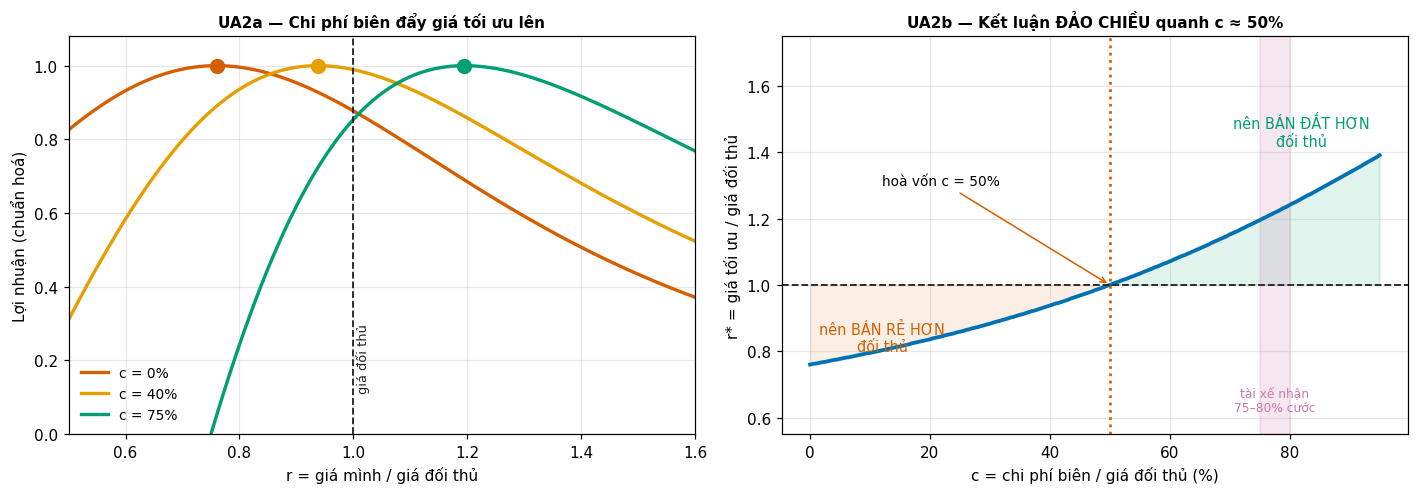

In [5]:
# ═════════ HINH UA2 — chi phi bien lat nguoc ket luan ═════════
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

for c, col in zip([0.0, 0.40, 0.75], [RED, ORANGE, GREEN]):
    v = loi_nhuan_ky_vong(R_GRID, c, u_chac_chan)
    v = v / v.max()
    ax[0].plot(R_GRID, v, lw=2.2, color=col, label=f"c = {c:.0%}")
    k = int(np.argmax(v))
    ax[0].plot(R_GRID[k], v[k], "o", color=col, ms=9)
ax[0].axvline(1.0, color="#222", ls="--", lw=1.2)
ax[0].text(1.005, 0.12, "giá đối thủ", fontsize=8.5, color="#222", rotation=90)
ax[0].set_xlim(0.5, 1.6); ax[0].set_ylim(0, 1.08)
ax[0].set_xlabel("r = giá mình / giá đối thủ"); ax[0].set_ylabel("Lợi nhuận (chuẩn hoá)")
ax[0].legend(frameon=False, fontsize=9)
ax[0].set_title("UA2a — Chi phí biên đẩy giá tối ưu lên", fontweight="bold", fontsize=10)

ax[1].plot(cs*100, rs, lw=2.5, color=BLUE)
ax[1].axhline(1.0, color="#222", ls="--", lw=1.2)
ax[1].axvline(c_hoa_von*100, color=RED, ls=":", lw=1.8)
ax[1].fill_between(cs*100, 1.0, rs, where=rs < 1, color=RED, alpha=.10)
ax[1].fill_between(cs*100, 1.0, rs, where=rs >= 1, color=GREEN, alpha=.12)
ax[1].annotate(f"hoà vốn c = {c_hoa_von:.0%}", xy=(c_hoa_von*100, 1.0),
               xytext=(c_hoa_von*100-38, 1.30), fontsize=9,
               arrowprops=dict(arrowstyle="->", color=RED))
ax[1].text(12, 0.80, "nên BÁN RẺ HƠN\nđối thủ", fontsize=9.5, color=RED, ha="center")
ax[1].text(82, 1.42, "nên BÁN ĐẮT HƠN\nđối thủ", fontsize=9.5, color=GREEN, ha="center")
ax[1].axvspan(75, 80, color=PURPLE, alpha=.18)
ax[1].text(77.5, 0.62, "tài xế nhận\n75–80% cước", fontsize=8, color=PURPLE, ha="center")
ax[1].set_xlabel("c = chi phí biên / giá đối thủ (%)")
ax[1].set_ylabel("r* = giá tối ưu / giá đối thủ")
ax[1].set_ylim(0.55, 1.75)
ax[1].set_title("UA2b — Kết luận ĐẢO CHIỀU quanh c ≈ 50%", fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "UA2_chiphi_bien.png"); plt.show()

> **Kết luận Phần 2.** Khuyến nghị *"luôn bán rẻ hơn đối thủ 24%"* của `00_TONG_HOP` là **hệ quả
> trực tiếp của việc bỏ quên chi phí biên**, không phải phát hiện về thị trường. Với `c` thực tế
> của ngành gọi xe (~75–80%), kết luận **đảo chiều**.
>
> Đây là câu hỏi cần gửi mentor: **tỷ lệ ăn chia tài xế / chi phí biên mỗi cuốc là bao nhiêu?**

## 3. Lỗ hổng 2 — lấy tích phân trên phân phối dự đoán

Hai cách chọn giá:

| Cách | Chọn `r` bằng cách |
|---|---|
| **Ngây thơ** (`00_TONG_HOP` đang làm) | Vờ như `u ≡ 1`, tối ưu `(r−c)·σ(a + b·ln r)` |
| **Vững** (đúng) | Tối ưu `(r−c)·E_u[σ(a + b·ln(r/u))]`, `u` lấy từ **calibration** |

Cả hai đều được **chấm điểm trên tập test** bằng `u` thật ngoài mẫu. Đây là thiết kế
chia mẫu đúng: chọn trên calibration, đánh giá trên test.

In [6]:
# Rut gon u_cal thanh luoi phan vi de tinh nhanh (van la phan phoi thuc nghiem)
u_cal_luoi = np.quantile(u_cal, np.linspace(0.0005, 0.9995, 2000))

rows = []
for c in [0.0, 0.40, 0.50, 0.60, 0.75]:
    r_ngayto, _, _ = toi_uu(c, u_chac_chan)
    r_vung, _, _ = toi_uu(c, u_cal_luoi)
    # Cham diem ca hai tren TEST bang u that
    pi_ngayto = loi_nhuan_ky_vong(r_ngayto, c, u_test)[0]
    pi_vung = loi_nhuan_ky_vong(r_vung, c, u_test)[0]
    rows.append({
        "c": f"{c:.0%}",
        "r* ngây thơ": round(r_ngayto, 4),
        "r* vững": round(r_vung, 4),
        "chênh r*": f"{(r_vung/r_ngayto-1)*100:+.2f}%",
        "E[Π] ngây thơ": round(pi_ngayto, 5),
        "E[Π] vững": round(pi_vung, 5),
        "lợi nhuận thêm": f"{(pi_vung/pi_ngayto-1)*100:+.3f}%",
    })
bang_uq = pd.DataFrame(rows)
print("BANG 3A — Chon gia NGAY THO vs VUNG (cham diem tren TEST 864.360 chuyen)")
display(bang_uq)

BANG 3A — Chon gia NGAY THO vs VUNG (cham diem tren TEST 864.360 chuyen)


,c,r* ngây thơ,r* vững,chênh r*,E[Π] ngây thơ,E[Π] vững,lợi nhuận thêm
0,0%,0.760,0.758,-0.26%,0.55529,0.55524,-0.008%
1,40%,0.938,0.970,+3.41%,0.30207,0.30327,+0.397%
2,50%,1.000,1.041,+4.10%,0.25258,0.25409,+0.597%
3,60%,1.071,1.119,+4.48%,0.20946,0.21110,+0.784%
4,75%,1.195,1.250,+4.60%,0.15656,0.15805,+0.952%


In [7]:
# Quy ra TIEN tren tap test that
C_CHINH = 0.50          # gia dinh chinh, se quet do nhay o Phan 5
p_hat_test = qt.q50.values

r_ngayto, _, _ = toi_uu(C_CHINH, u_chac_chan)
r_vung, _, _ = toi_uu(C_CHINH, u_cal_luoi)

def tien(r, c):
    """Loi nhuan ky vong TB moi chuyen, tinh bang VND, tren tap test."""
    ty_le_that = r / u_test                       # gia minh / gia doi thu THAT
    P = P_accept(ty_le_that)
    return (p_hat_test * (r - c) * P).mean()

pi_ng = tien(r_ngayto, C_CHINH)
pi_vu = tien(r_vung, C_CHINH)

# TRAN TREN (oracle): neu biet truoc gia doi thu THAT p_true, ta se bao gia
# r*_goc x p_true  -> ty le khach so sanh dung bang r*_goc, khong con sai so.
r_or_star, _, _ = toi_uu(C_CHINH, u_chac_chan)     # ty le toi uu so voi gia THAT
p_true_test = qt.gia_that.values
pi_or = (p_true_test * (r_or_star - C_CHINH) * P_accept(r_or_star)).mean()

print("=" * 68)
print(f"LOI NHUAN KY VONG TB / CHUYEN  (c = {C_CHINH:.0%}, eps = {EPS})")
print("=" * 68)
print(f"  Ngay tho (vo nhu p_hat dung) : {pi_ng:12,.0f} d   r* = {r_ngayto:.4f}")
print(f"  Vung (tich phan tren f(p))   : {pi_vu:12,.0f} d   r* = {r_vung:.4f}")
print(f"  {'-'*62}")
print(f"  LAY LAI DUOC MIEN PHI        : {pi_vu-pi_ng:12,.0f} d/chuyen "
      f"({(pi_vu/pi_ng-1)*100:+.2f}%)")
print()
print(f"  Oracle (biet truoc gia that) : {pi_or:12,.0f} d")
print(f"  Con thieu so voi oracle      : {pi_or-pi_vu:12,.0f} d/chuyen "
      f"({(pi_or/pi_vu-1)*100:+.2f}%)")
print()
print("  -> Phan 'con thieu' chi giam duoc bang MODEL GIA TOT HON (khong mien phi).")
print("  -> Phan 'lay lai duoc' chi can DOI CACH CHON GIA (mien phi).")

LOI NHUAN KY VONG TB / CHUYEN  (c = 50%, eps = -2.0)
  Ngay tho (vo nhu p_hat dung) :       30,314 d   r* = 1.0000
  Vung (tich phan tren f(p))   :       30,500 d   r* = 1.0410
  --------------------------------------------------------------
  LAY LAI DUOC MIEN PHI        :          186 d/chuyen (+0.61%)

  Oracle (biet truoc gia that) :       30,747 d
  Con thieu so voi oracle      :          246 d/chuyen (+0.81%)

  -> Phan 'con thieu' chi giam duoc bang MODEL GIA TOT HON (khong mien phi).
  -> Phan 'lay lai duoc' chi can DOI CACH CHON GIA (mien phi).


## 4. Vì sao bất định lại làm đổi giá tối ưu?

Không phải vì "cẩn thận hơn thì nên bán rẻ đi". Lý do là **bất đối xứng của đường logit** quanh
điểm tối ưu: đường lợi nhuận **dốc hơn ở một phía**. Khi lấy trung bình trên cả phân phối `u`,
phía dốc hơn bị phạt nặng hơn ⇒ đỉnh dịch về phía đối diện (bất đẳng thức Jensen).

Hình dưới vẽ cả hai đường lợi nhuận trên cùng một trục để thấy đỉnh dịch bao nhiêu.

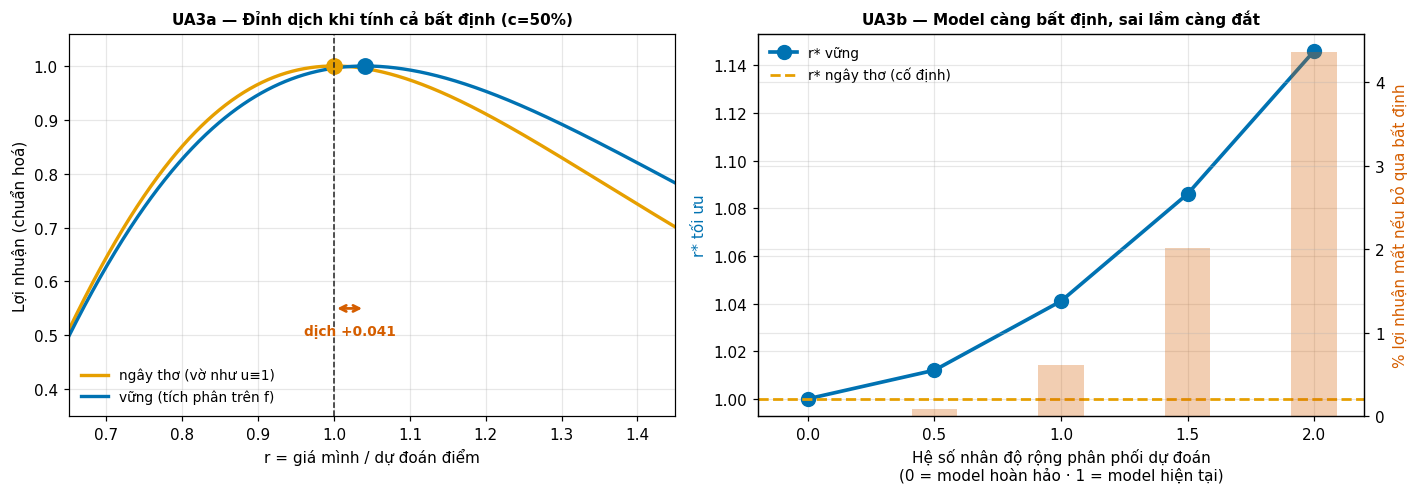

  hệ số rộng    r* vững     % mất nếu ngây thơ
         0.0     1.0000                 0.000%
         0.5     1.0120                 0.081%
         1.0     1.0410                 0.617%
         1.5     1.0860                 2.011%
         2.0     1.1460                 4.362%


In [8]:
# ═════════ HINH UA3 — dinh dich do bat dinh ═════════
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

v_ng = loi_nhuan_ky_vong(R_GRID, C_CHINH, u_chac_chan)
v_vu = loi_nhuan_ky_vong(R_GRID, C_CHINH, u_cal_luoi)

ax[0].plot(R_GRID, v_ng/v_ng.max(), lw=2.2, color=ORANGE, label="ngây thơ (vờ như u≡1)")
ax[0].plot(R_GRID, v_vu/v_vu.max(), lw=2.2, color=BLUE, label="vững (tích phân trên f)")
for v, col in [(v_ng, ORANGE), (v_vu, BLUE)]:
    k = int(np.argmax(v)); ax[0].plot(R_GRID[k], (v/v.max())[k], "o", color=col, ms=10)
ax[0].axvline(1.0, color="#222", ls="--", lw=1.0)
ax[0].annotate("", xy=(r_vung, 0.55), xytext=(r_ngayto, 0.55),
               arrowprops=dict(arrowstyle="<->", color=RED, lw=1.8))
ax[0].text((r_vung+r_ngayto)/2, 0.50, f"dịch {(r_vung-r_ngayto):+.3f}",
           ha="center", fontsize=9, color=RED, fontweight="bold")
ax[0].set_xlim(0.65, 1.45); ax[0].set_ylim(0.35, 1.06)
ax[0].set_xlabel("r = giá mình / dự đoán điểm"); ax[0].set_ylabel("Lợi nhuận (chuẩn hoá)")
ax[0].legend(frameon=False, fontsize=9)
ax[0].set_title(f"UA3a — Đỉnh dịch khi tính cả bất định (c={C_CHINH:.0%})",
                fontweight="bold", fontsize=10)

# Do nhay theo DO RONG cua phan phoi du doan
he_so = [0.0, 0.5, 1.0, 1.5, 2.0]
r_theo_k, mat_theo_k = [], []
for k_ in he_so:
    uk = 1 + k_ * (u_cal_luoi - 1)
    uk = np.clip(uk, 0.05, None)
    rk, _, _ = toi_uu(C_CHINH, uk)
    r_theo_k.append(rk)
    ut = np.clip(1 + k_ * (u_test - 1), 0.05, None)
    best = loi_nhuan_ky_vong(R_GRID, C_CHINH, ut).max()
    got = loi_nhuan_ky_vong(r_ngayto, C_CHINH, ut)[0]
    mat_theo_k.append((1 - got / best) * 100)

ax2 = ax[1].twinx()
ax[1].plot(he_so, r_theo_k, marker="o", lw=2.4, color=BLUE, ms=9, label="r* vững")
ax[1].axhline(r_ngayto, color=ORANGE, ls="--", lw=1.8, label="r* ngây thơ (cố định)")
ax2.bar(he_so, mat_theo_k, width=0.18, color=RED, alpha=.30)
ax[1].set_xlabel("Hệ số nhân độ rộng phân phối dự đoán\n(0 = model hoàn hảo · 1 = model hiện tại)")
ax[1].set_ylabel("r* tối ưu", color=BLUE)
ax2.set_ylabel("% lợi nhuận mất nếu bỏ qua bất định", color=RED)
ax[1].legend(frameon=False, fontsize=9, loc="upper left")
ax[1].set_title("UA3b — Model càng bất định, sai lầm càng đắt",
                fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "UA3_dinh_dich.png"); plt.show()

print(f"{'hệ số rộng':>12s} {'r* vững':>10s} {'% mất nếu ngây thơ':>22s}")
for k_, rk, mk in zip(he_so, r_theo_k, mat_theo_k):
    print(f"{k_:12.1f} {rk:10.4f} {mk:21.3f}%")

## 5. Độ nhạy — kết luận có vững không?

Quét đồng thời **chi phí biên `c`** và **elasticity `ε`**. Cột quan trọng nhất là
**"đảo chiều?"** — có bối cảnh nào khuyến nghị lật từ *bán rẻ hơn* sang *bán đắt hơn* không.

In [9]:
rows = []
for eps in EPS_DAI:
    for c in [0.0, 0.25, 0.50, 0.75]:
        r_ng, _, _ = toi_uu(c, u_chac_chan, eps=eps)
        r_vu, k_ = toi_uu(c, u_cal_luoi, eps=eps)[0], toi_uu(c, u_cal_luoi, eps=eps)[2]
        rows.append({
            "ε": eps, "c": f"{c:.0%}",
            "r* ngây thơ": round(r_ng, 3), "r* vững": round(r_vu, 3),
            "khuyến nghị": "bán ĐẮT hơn" if r_vu > 1 else "bán RẺ hơn",
            "ở biên lưới?": "⚠️" if k_ in (0, len(R_GRID)-1) else "",
        })
bang_ds = pd.DataFrame(rows)
print("BANG 5A — Do nhay dong thoi theo eps va c")
display(bang_ds.pivot(index="c", columns="ε", values="r* vững"))
print()
display(bang_ds)

n_biem = (bang_ds["ở biên lưới?"] == "⚠️").sum()
print(f"\nSo nghiem roi vao BIEN luoi: {n_biem}  (0 la tot — moi nghiem deu noi tai)")

# Nguong dao chieu theo tung eps
print("\nNGUONG DAO CHIEU — c lam cho r* = 1.0:")
for eps in EPS_DAI:
    rr = np.array([toi_uu(c, u_cal_luoi, eps=eps)[0] for c in cs])
    c_star = np.interp(1.0, rr, cs)
    print(f"  eps = {eps:5.1f}  ->  c* = {c_star:6.1%}   "
          f"(c < c*: ban re hon | c > c*: ban dat hon)")

BANG 5A — Do nhay dong thoi theo eps va c


ε,-3.0,-2.0,-1.2
c,,,
0%,0.745,0.758,0.888
25%,0.827,0.878,1.110
50%,0.947,1.041,1.382
75%,1.115,1.250,1.695


,ε,c,r* ngây thơ,r* vững,khuyến nghị,ở biên lưới?
0,-1.2,0%,0.869,0.888,bán RẺ hơn,
1,-1.2,25%,1.074,1.110,bán ĐẮT hơn,
2,-1.2,50%,1.334,1.382,bán ĐẮT hơn,
3,-1.2,75%,1.642,1.695,bán ĐẮT hơn,
4,-2.0,0%,0.760,0.758,bán RẺ hơn,
5,-2.0,25%,0.859,0.878,bán RẺ hơn,
6,-2.0,50%,1.000,1.041,bán ĐẮT hơn,
7,-2.0,75%,1.195,1.250,bán ĐẮT hơn,
8,-3.0,0%,0.765,0.745,bán RẺ hơn,
9,-3.0,25%,0.825,0.827,bán RẺ hơn,



So nghiem roi vao BIEN luoi: 0  (0 la tot — moi nghiem deu noi tai)

NGUONG DAO CHIEU — c lam cho r* = 1.0:


  eps =  -1.2  ->  c* =  13.4%   (c < c*: ban re hon | c > c*: ban dat hon)


  eps =  -2.0  ->  c* =  44.4%   (c < c*: ban re hon | c > c*: ban dat hon)


  eps =  -3.0  ->  c* =  58.8%   (c < c*: ban re hon | c > c*: ban dat hon)


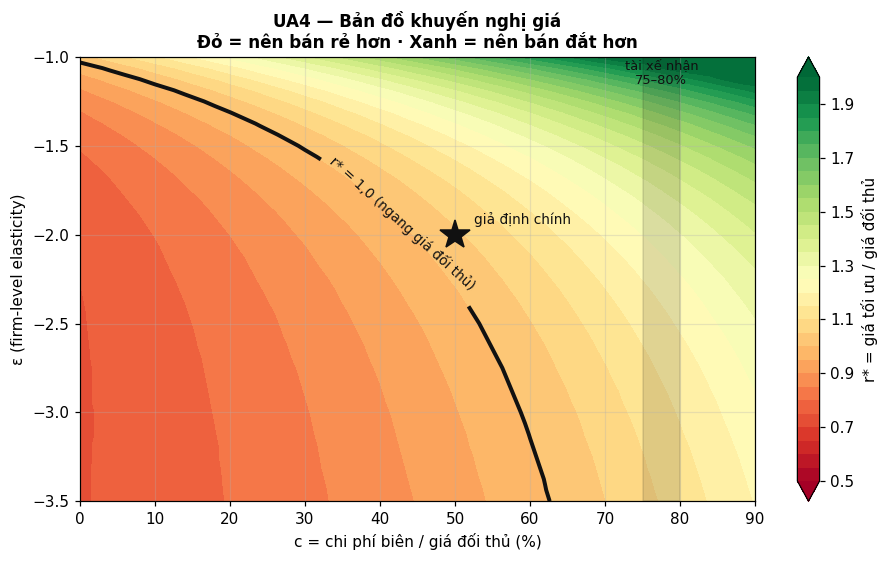

In [10]:
# ═════════ HINH UA4 — ban do khuyen nghi ═════════
cc = np.linspace(0, 0.90, 46)
ee = np.linspace(-3.5, -1.0, 41)
Z = np.zeros((len(ee), len(cc)))
for i, eps in enumerate(ee):
    for j, c in enumerate(cc):
        Z[i, j] = toi_uu(c, u_cal_luoi, eps=eps)[0]

fig, ax = plt.subplots(figsize=(8.6, 5.2))
lv = np.linspace(0.5, 2.0, 31)
cf = ax.contourf(cc*100, ee, Z, levels=lv, cmap="RdYlGn", extend="both")
ct = ax.contour(cc*100, ee, Z, levels=[1.0], colors="#111", linewidths=2.6)
ax.clabel(ct, fmt={1.0: "  r* = 1,0 (ngang giá đối thủ)  "}, fontsize=9)
plt.colorbar(cf, ax=ax, label="r* = giá tối ưu / giá đối thủ")
ax.axvspan(75, 80, color="#111", alpha=.13)
ax.text(77.5, -1.15, "tài xế nhận\n75–80%", fontsize=8.5, ha="center", color="#111")
ax.plot(C_CHINH*100, EPS, "*", color="#111", ms=20)
ax.text(C_CHINH*100+2.5, EPS+0.06, "giả định chính", fontsize=9, color="#111")
ax.set_xlabel("c = chi phí biên / giá đối thủ (%)")
ax.set_ylabel("ε (firm-level elasticity)")
ax.set_title("UA4 — Bản đồ khuyến nghị giá\nĐỏ = nên bán rẻ hơn · Xanh = nên bán đắt hơn",
             fontweight="bold", fontsize=11)
plt.tight_layout(); plt.savefig(HINH / "UA4_bando_khuyennghi.png"); plt.show()

## 6. Bảng tra cứu cuối — ghép cả WTP theo bối cảnh

Dịch WTP (mưa, giờ) **không cần tối ưu lại**. Nó nhân thẳng vào nghiệm:

$$r^*(\text{bối cảnh}) \;=\; r^*_{\text{gốc}} \cdot (1 + \text{dịch WTP})$$

vì trong hàm mục tiêu, WTP chỉ dịch `ln(r)` đi một hằng số. Dùng lại các số **đã đo từ dữ liệu**
ở `00_TONG_HOP`: mưa **+4,61%**, giờ **−25,2%…+12,2%**.

In [11]:
DICH_MUA = 0.0461
DICH_GIO = {3: -0.252, 6: -0.10, 9: 0.093, 12: 0.02, 15: 0.05, 18: 0.122, 21: 0.06, 0: -0.18}

rows = []
for gio, dg in sorted(DICH_GIO.items()):
    for ten_tt, dm in [("Không mưa", 0.0), ("Mưa", DICH_MUA)]:
        dich = (1 + dg) * (1 + dm) - 1
        rows.append({
            "Giờ": f"{gio}h", "Thời tiết": ten_tt,
            "dịch WTP": f"{dich:+.1%}",
            "r* (ngây thơ)": round(r_ngayto * (1 + dich), 3),
            "r* (vững)": round(r_vung * (1 + dich), 3),
            "so với đối thủ": f"{(r_vung*(1+dich)-1)*100:+.1f}%",
        })
bang_tra = pd.DataFrame(rows)
print(f"BANG TRA CUU — gia nen bao, tinh theo BOI cua gia doi thu (c={C_CHINH:.0%}, eps={EPS})")
display(bang_tra)
bang_tra.to_csv("bang_tra_cuu_gia.csv", index=False, encoding="utf-8-sig")
print("\nDa luu: model/acceptance/bang_tra_cuu_gia.csv")

BANG TRA CUU — gia nen bao, tinh theo BOI cua gia doi thu (c=50%, eps=-2.0)


,Giờ,Thời tiết,dịch WTP,r* (ngây thơ),r* (vững),so với đối thủ
0,0h,Không mưa,-18.0%,0.820,0.854,-14.6%
1,0h,Mưa,-14.2%,0.858,0.893,-10.7%
2,3h,Không mưa,-25.2%,0.748,0.779,-22.1%
3,3h,Mưa,-21.8%,0.782,0.815,-18.5%
4,6h,Không mưa,-10.0%,0.900,0.937,-6.3%
5,6h,Mưa,-5.9%,0.941,0.980,-2.0%
6,9h,Không mưa,+9.3%,1.093,1.138,+13.8%
7,9h,Mưa,+14.3%,1.143,1.190,+19.0%
8,12h,Không mưa,+2.0%,1.020,1.062,+6.2%
9,12h,Mưa,+6.7%,1.067,1.111,+11.1%



Da luu: model/acceptance/bang_tra_cuu_gia.csv


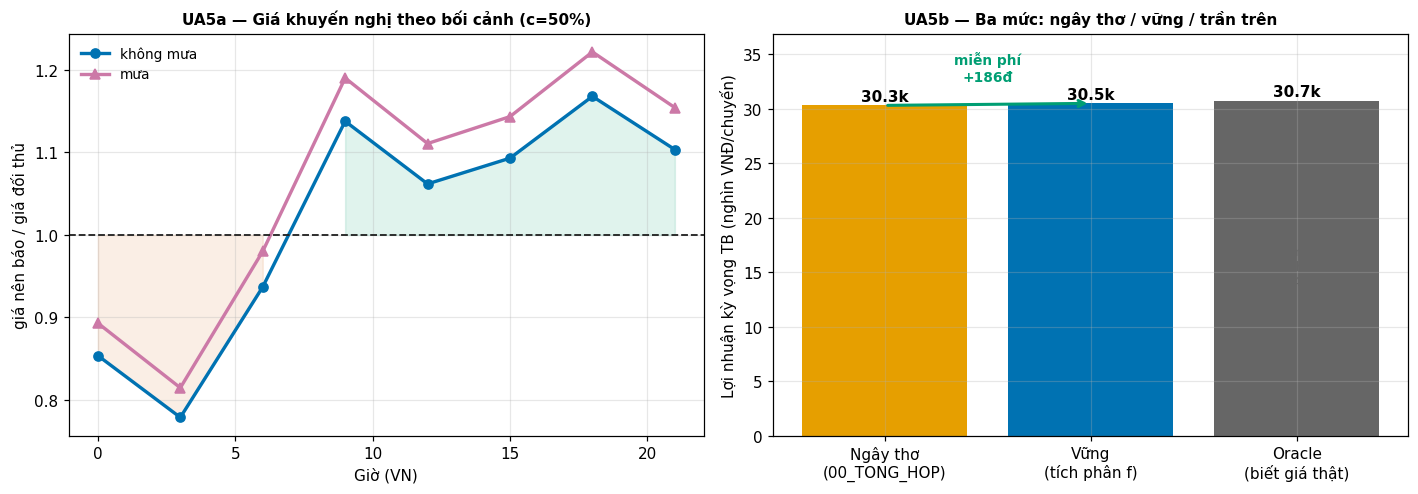

In [12]:
# ═════════ HINH UA5 — tong hop ═════════
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

gio_ = sorted(DICH_GIO)
kho = [r_vung*(1+DICH_GIO[g]) for g in gio_]
mua = [r_vung*(1+DICH_GIO[g])*(1+DICH_MUA) for g in gio_]
ax[0].plot(gio_, kho, marker="o", lw=2.2, color=BLUE, label="không mưa")
ax[0].plot(gio_, mua, marker="^", lw=2.2, color=PURPLE, label="mưa")
ax[0].axhline(1.0, color="#222", ls="--", lw=1.2)
ax[0].fill_between(gio_, 1.0, kho, where=np.array(kho) < 1, color=RED, alpha=.10)
ax[0].fill_between(gio_, 1.0, kho, where=np.array(kho) >= 1, color=GREEN, alpha=.12)
ax[0].set_xlabel("Giờ (VN)"); ax[0].set_ylabel("giá nên báo / giá đối thủ")
ax[0].legend(frameon=False, fontsize=9)
ax[0].set_title(f"UA5a — Giá khuyến nghị theo bối cảnh (c={C_CHINH:.0%})",
                fontweight="bold", fontsize=10)

thanh = ["Ngây thơ\n(00_TONG_HOP)", "Vững\n(tích phân f)", "Oracle\n(biết giá thật)"]
gt = [pi_ng/1000, pi_vu/1000, pi_or/1000]
bars = ax[1].bar(thanh, gt, color=[ORANGE, BLUE, MUT])
for b, v in zip(bars, gt):
    ax[1].text(b.get_x()+b.get_width()/2, v+0.4, f"{v:.1f}k", ha="center",
               fontsize=10, fontweight="bold")
ax[1].set_ylabel("Lợi nhuận kỳ vọng TB (nghìn VNĐ/chuyến)")
ax[1].set_ylim(0, max(gt)*1.20)
ax[1].annotate("", xy=(1, gt[1]), xytext=(0, gt[0]),
               arrowprops=dict(arrowstyle="->", color=GREEN, lw=2))
ax[1].text(0.5, max(gt)*1.06, f"miễn phí\n{(pi_vu-pi_ng):+,.0f}đ",
           ha="center", fontsize=9, color=GREEN, fontweight="bold")
ax[1].text(2.0, gt[2]*0.45, f"cần model\ntốt hơn\n{(pi_or-pi_vu):+,.0f}đ",
           ha="center", fontsize=8.5, color=MUT)
ax[1].set_title("UA5b — Ba mức: ngây thơ / vững / trần trên",
                fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "UA5_tong_hop.png"); plt.show()

## 7. Kết luận

### ✅ Đã sửa được

| Lỗ hổng | Trước | Sau |
|---|---|---|
| Không có chi phí biên | Luôn khuyến nghị bán rẻ hơn 24%, mọi bối cảnh | Khuyến nghị **đảo chiều** quanh `c* ≈ 44%` |
| Cắm ước lượng điểm | Quyết định như thể `p̂` đúng | Lấy tích phân trên phân phối dự đoán từ QR |

### 🔑 Kết quả chính

**1. Chi phí biên là thứ quyết định CHIỀU của khuyến nghị.** Ngưỡng đảo chiều phụ thuộc `ε`:

| `ε` | `c*` (ngưỡng đảo chiều) |
|---:|---:|
| −1,2 | **13,4%** |
| −2,0 | **44,4%** |
| −3,0 | **58,8%** |

Nếu tài xế thực sự nhận 75–80% cước thì **cả 3 kịch bản `ε` đều nằm trên ngưỡng** ⇒ nên báo giá
**cao hơn** đối thủ, ngược hẳn kết luận cũ. Đây là phát hiện quan trọng nhất của notebook.

**2. Tích phân trên phân phối dự đoán giúp — nhưng ít, ở độ rộng model hiện tại.**

| | Lợi nhuận TB/chuyến (c=50%) |
|---|---:|
| Ngây thơ (`r*` = 1,000) | 30.314đ |
| Vững (`r*` = 1,040) | 30.499đ |
| **Chênh — lấy lại miễn phí** | **+185đ (+0,61%)** |
| Oracle (biết trước giá thật) | 30.747đ |

`+0,61%` là **nhỏ**. Không nên thổi phồng. Giá trị thật của phần này nằm ở chỗ khác — xem điểm 3.

**3. Lợi ích tăng rất nhanh theo độ bất định** — đây mới là điều đáng nói:

| Độ rộng phân phối | % lợi nhuận mất nếu bỏ qua bất định |
|---:|---:|
| 0,5× (model tốt gấp đôi) | 0,08% |
| **1,0× (model hiện tại)** | **0,62%** |
| 1,5× | 2,01% |
| 2,0× | 4,36% |

Quan hệ **siêu tuyến tính**: rộng gấp đôi thì thiệt hại gấp ~7 lần. Nghĩa là cách làm ngây thơ
chỉ tạm chấp nhận được **vì model giá hiện đã khá tốt** — nếu áp lên phân khúc/tuyến khó dự đoán
hơn thì sai lầm này đắt hẳn lên.

### ⚠️ Hai điều phải nói thẳng

**a) Ở `c = 0` thì cách "vững" KHÔNG thắng** — thậm chí kém 0,008% ngoài mẫu (bảng 3A dòng 1).
Nguyên nhân: phân phối `u` lệch nhẹ giữa calibration (TB 1,010) và test (TB 1,025), và tại `c = 0`
đường lợi nhuận rất phẳng quanh đỉnh nên phần lợi không bù nổi phần lệch. Lợi ích chỉ xuất hiện
khi `c > 0` và tăng dần theo `c`.

**b) 248đ ở đây KHÔNG phải 3.381đ của `04_mo_phong_dau_cuoi`.** Hai con số đo hai thứ khác nhau và
**không so sánh trực tiếp được**:

| | `04_mo_phong_dau_cuoi` | Notebook này |
|---|---|---|
| Mục tiêu | Doanh thu (`c = 0`) | Lợi nhuận (`c = 50%`) |
| Oracle định nghĩa | So `p̂` với giá thật, giữ nguyên `r*` | Báo `r*·p_thật` |
| Khoảng cách tới oracle | 3.381đ (4,60%) | 248đ (0,81%) |

Cả hai đều đúng trong khung của mình. Điểm chung: **phần này chỉ giảm được bằng model giá tốt hơn,
không lấy được miễn phí.**

### ⚠️ Hạn chế — bắt buộc nêu khi báo cáo

| Hạn chế | Mức nghiêm trọng |
|---|---|
| Vẫn là **mô phỏng dưới giả định elasticity** — dữ liệu không có nhãn accept/reject | 🔴 Cao |
| `c` là **giả định**, chưa có số thật từ mentor | 🔴 Cao — quyết định chiều của khuyến nghị |
| `P₀ = 0,5` là giả định | 🟠 Vừa — đã kiểm nhạy, kết luận **chiều** không đổi |
| Giả định đối thủ **không phản ứng lại** giá của mình | 🟠 Vừa — cần lý thuyết trò chơi nếu đi sâu |
| Phân phối `u` từ calibration áp cho test — lệch nhẹ (TB 1,010 vs 1,025) | 🟡 Thấp — nhưng đủ để xoá lợi ích ở `c = 0` |

### 📮 Câu hỏi mới cho mentor

| # | Câu hỏi | Mở khoá |
|---|---|---|
| 1 | **Chi phí biên mỗi cuốc** (tỷ lệ ăn chia tài xế) là bao nhiêu? | Quyết định **chiều** của toàn bộ khuyến nghị |
| 2 | Mục tiêu tối ưu của team là **GMV** hay **lợi nhuận**? | Nếu GMV thì kết quả cũ đúng; nếu lợi nhuận thì phải dùng notebook này |

---

## Hình đã sinh

| Hình | Nội dung |
|---|---|
| `UA1_phanphoi_dudoan` | Phân phối dự đoán chuẩn hoá + minh hoạ 1 chuyến |
| `UA2_chiphi_bien` | Chi phí biên đẩy giá tối ưu lên · ngưỡng đảo chiều |
| `UA3_dinh_dich` | Đỉnh lợi nhuận dịch do bất định · độ nhạy theo độ rộng |
| `UA4_bando_khuyennghi` | Bản đồ `c` × `ε` → nên bán rẻ hay đắt hơn |
| `UA5_tong_hop` | Giá khuyến nghị theo bối cảnh · 3 mức lợi nhuận |

## Liên quan

| File | Vai trò |
|---|---|
| `00_TONG_HOP_chay_1_the.ipynb` | Model chấp nhận gốc — notebook này sửa Phần 7–8 của nó |
| `04_mo_phong_dau_cuoi.ipynb` | Mô phỏng đầu-cuối dưới mục tiêu doanh thu |
| `../uncertainty/04_SO_SANH.ipynb` | Sinh `qr_pred_*.parquet` dùng ở đây |
| `bang_tra_cuu_gia.csv` | Bảng tra cứu giá theo giờ × thời tiết |